In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from model.small_cnn import SmallCNN
import matplotlib.pyplot as plt
import random
import torch.nn as nn
import numpy as np

In [2]:
transform = transforms.Compose([transforms.Resize((64,64)),transforms.ToTensor(),])

In [3]:
data_dir = r"D:\PROJECTS\fruit-leaf-classification-cnn\data\fruit_leaves"
full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)

print("Total images: ", len(full_dataset))
print("Classes (label order): ")
for i, name in enumerate(full_dataset.classes):
    print(f" {i}: {name}")

Total images:  3173
Classes (label order): 
 0: Aegle marmelos
 1: Black plum
 2: Custard Apple
 3: Guava
 4: Jackfruit
 5: Lotkon
 6: Lychee
 7: Mango
 8: Plum
 9: Star Fruit


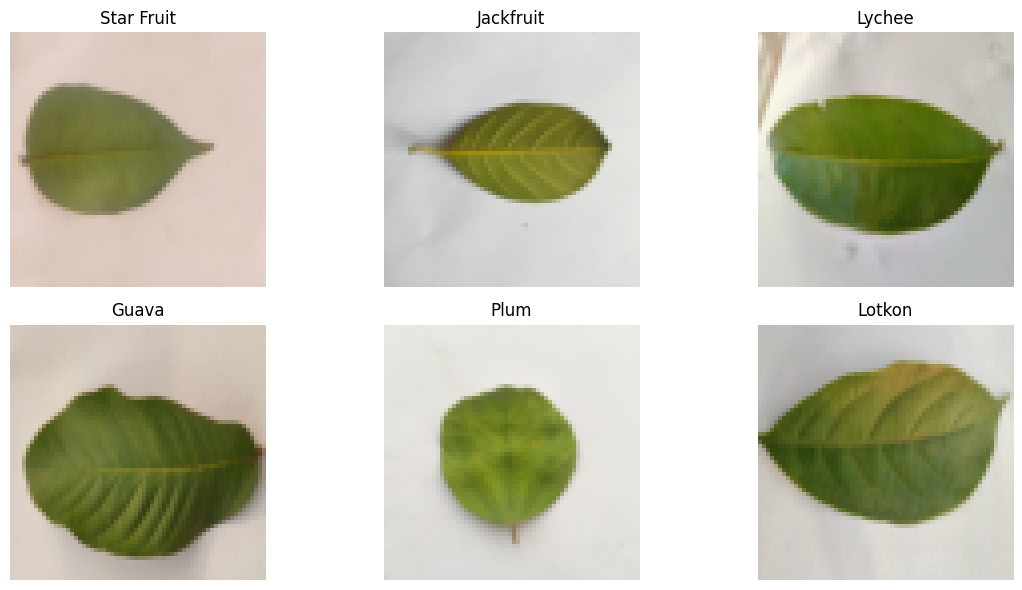

In [4]:
plt.figure(figsize=(12,6))
for i in range(6):
    idx = random.randint(0,len(full_dataset)-1)

    # image is a tensor (3, 64, 64)
    image, label = full_dataset[idx]   
    # rearrange to (64, 64, 3) for display
    image_to_show = image.permute(1,2,0)
    
    plt.subplot(2,3,i+1)
    plt.imshow(image_to_show)
    plt.title(full_dataset.classes[label])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [5]:
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size = 32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size = 32, shuffle=False)

print(f"Training images: {train_size}")
print(f"Test images: {test_size}")

Training images: 2538
Test images: 635


In [6]:
model = SmallCNN(n_classes=10)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)
print(model)

SmallCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=8192, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)


In [7]:
epochs = 8

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs} - Average Loss: {avg_loss:.4f}")
print("Done training")

C:\Users\rupal\AppData\Local\Programs\Python\Python313\Lib\site-packages\PIL\Image.py:3574: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs,1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy on {total} unseen leaf images: {accuracy:.2f}%")

In [ ]:
def dataset_to_arrays(dataset):
    X, y = [], []
    for image, label in dataset:
        X.append(image.numpy().flatten())
        y.append(label)
    return np.array(X), np.array(y)

X_train, y_train = dataset_to_arrays(train_dataset)
X_test, y_test = dataset_to_arrays(test_dataset)

print("X_train shape: ", X_train.shape)
print("X_test shape: ", X_test.shape)
print("Pixel value range: ", X_train.min(), " to ", X_train.max())

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=101, n_jobs=-1)

print("Training Random Forest model")

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
rf_accuracy = 100 * accuracy_score(y_test, rf_preds)

print(f"Random Forest model Accuracy: {rf_accuracy:.2f}%")

In [ ]:
def cnn_accuracy(loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
      for images, labels in loader:
          outputs = model(images)
          _, predicted = torch.max(outputs, 1)
          total += labels.size(0)
          correct += (predicted == labels).sum().item()
    return 100 * correct / total

train_acc = cnn_accuracy(train_loader)
test_acc  = cnn_accuracy(test_loader)

print(f"CNN train accuracy: {train_acc:.2f}%")
print(f"CNN test accuracy:  {test_acc:.2f}%")
print(f"Gap (train - test): {train_acc - test_acc:.2f}%")

In [ ]:
print("Train size:", len(train_dataset), "| Test size:", len(test_dataset))
print("Total:", len(train_dataset) + len(test_dataset), "| Dataset:",
len(full_dataset))
print("No overlap if total == dataset:", len(train_dataset) + len(test_dataset) ==
len(full_dataset))

from sklearn.metrics import accuracy_score
rf_train_acc = 100 * accuracy_score(y_train, rf_model.predict(X_train))
rf_test_acc  = 100 * accuracy_score(y_test, rf_model.predict(X_test))
print(f"\nRF train accuracy: {rf_train_acc:.2f}%")
print(f"RF test accuracy:  {rf_test_acc:.2f}%")

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

class_names = full_dataset.classes

# --- Get CNN predictions on the test set ---
model.eval()
cnn_preds, cnn_true = [], []
with torch.no_grad():
  for images, labels in test_loader:
      outputs = model(images)
      _, predicted = torch.max(outputs, 1)
      cnn_preds.extend(predicted.numpy())
      cnn_true.extend(labels.numpy())

# --- Plot both confusion matrices side by side ---
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# CNN
cm_cnn = confusion_matrix(cnn_true, cnn_preds)
ConfusionMatrixDisplay(cm_cnn, display_labels=class_names).plot(ax=axes[0],
xticks_rotation=45, cmap='Blues', colorbar=False)
axes[0].set_title("CNN (test acc 73.5%)")

# Random Forest
cm_rf = confusion_matrix(y_test, rf_model.predict(X_test))
ConfusionMatrixDisplay(cm_rf, display_labels=class_names).plot(ax=axes[1],
xticks_rotation=45, cmap='Greens', colorbar=False)
axes[1].set_title("Random Forest (test acc 92.6%)")

plt.tight_layout()
plt.savefig("figures/confusion_matrices.png", dpi=120, bbox_inches='tight')   
plt.show()

In [9]:
# AUGMENTED transform — for TRAINING only (random variations each time)
train_transform = transforms.Compose([
  transforms.Resize((64, 64)),
  transforms.RandomHorizontalFlip(),       # randomly flip left-right
  transforms.RandomRotation(20),           # randomly rotate up to 20 degrees
  transforms.ColorJitter(brightness=0.2, contrast=0.2),  # vary lighting
  transforms.ToTensor(),
])

# PLAIN transform — for TESTING (no augmentation, honest exam)
test_transform = transforms.Compose([
  transforms.Resize((64, 64)),
  transforms.ToTensor(),
])

In [10]:
# Re-create datasets with SEPARATE transforms (train augmented, test plain)
# Load the SAME folder twice, with different transforms attached
train_full = datasets.ImageFolder(root=data_dir, transform=train_transform)
test_full  = datasets.ImageFolder(root=data_dir, transform=test_transform)

In [11]:
# Same split as before, fixed seed so it's reproducible & fair
generator = torch.Generator().manual_seed(42)
train_idx, test_idx = random_split(range(len(train_full)), [train_size, test_size], generator=generator)

In [12]:
from torch.utils.data import Subset
train_dataset_aug = Subset(train_full, train_idx.indices)   # augmented
test_dataset_aug  = Subset(test_full,  test_idx.indices)    # plain

train_loader_aug = DataLoader(train_dataset_aug, batch_size=32, shuffle=True)
test_loader_aug  = DataLoader(test_dataset_aug,  batch_size=32, shuffle=False)

print(f"Augmented training images: {len(train_dataset_aug)}")
print(f"Plain test images:        {len(test_dataset_aug)}")

Augmented training images: 2538
Plain test images:        635


In [13]:
# Fresh model for the augmentation experiment (don't reuse the trained one)
model_aug = SmallCNN(n_classes=10)
loss_fn_aug = nn.CrossEntropyLoss()
optimizer_aug = torch.optim.Adam(model_aug.parameters(), lr=0.001)

In [14]:
epochs = 8

for epoch in range(epochs):
  model_aug.train()
  running_loss = 0.0
  for images, labels in train_loader_aug:          # <-- augmented loader
      outputs = model_aug(images)
      loss = loss_fn_aug(outputs, labels)
      optimizer_aug.zero_grad()
      loss.backward()
      optimizer_aug.step()
      running_loss += loss.item()
  avg_loss = running_loss / len(train_loader_aug)
  print(f"Epoch {epoch+1}/{epochs} - Average Loss: {avg_loss:.4f}")
print("Done training (augmented)")

Epoch 1/8 - Average Loss: 2.2459
Epoch 2/8 - Average Loss: 1.8600
Epoch 3/8 - Average Loss: 1.5875
Epoch 4/8 - Average Loss: 1.4587
Epoch 5/8 - Average Loss: 1.3136
Epoch 6/8 - Average Loss: 1.2064
Epoch 7/8 - Average Loss: 1.2038
Epoch 8/8 - Average Loss: 1.0418
Done training (augmented)


In [17]:
def acc_of(m, loader):
    m.eval()
    correct = total = 0
    with torch.no_grad():
        for images, labels in loader:
            outputs = m(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

aug_train = acc_of(model_aug, train_loader_aug)
aug_test  = acc_of(model_aug, test_loader_aug)

print(f"Augmented CNN train accuracy: {aug_train:.2f}%")
print(f"Augmented CNN test accuracy:  {aug_test:.2f}%")
print(f"Gap (train - test):           {aug_train - aug_test:.2f}%")
print(f"\n--- Scoreboard ---")
print(f"Round 1 CNN (no aug): 73.54%")
print(f"Augmented CNN:        {aug_test:.2f}%")
print(f"Random Forest:        92.60%")
print(f"\nDid the CNN beat RF? {'Yes' if aug_test > 92.60 else 'No'}")

Augmented CNN train accuracy: 62.96%
Augmented CNN test accuracy:  67.09%
Gap (train - test):           -4.12%

--- Scoreboard ---
Round 1 CNN (no aug): 73.54%
Augmented CNN:        67.09%
Random Forest:        92.60%

Did the CNN beat RF? No
